# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'

# file_path = '../input/IGNORE_Brewster-ortho.tif'
file_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'


Image CRS - EPSG:32613


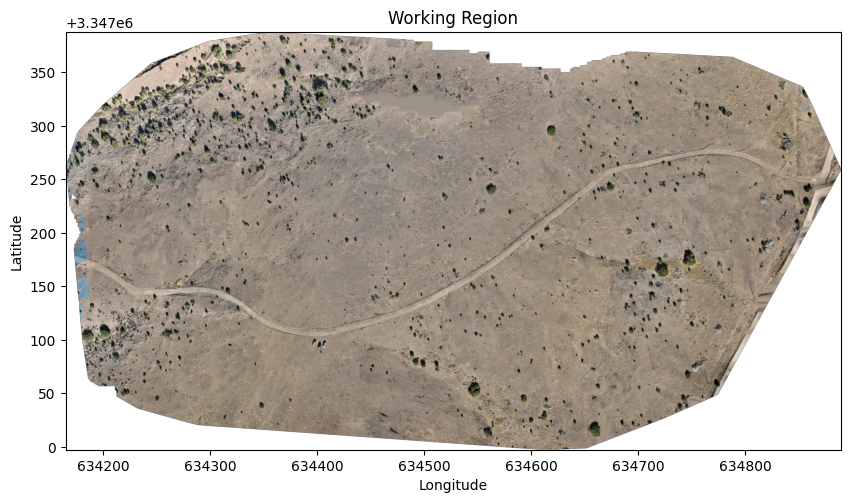

Image dimensions: (3535, 6559, 4)


In [2]:
from plant_search.load_image import load_image, plot_image, plot_geotiff

ds = 2 # downscale ratio

image, transform, bounds, image_crs = load_image(file_path)

# We have a georeferenced image
if image is not None and transform and bounds:
    original_image_shape = image.shape
    image = image[::ds, ::ds]
    # Calculate extent in geographic coordinates
    image_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    plot_geotiff(image, transform, bounds, "Working Region")

# We have image, but not georeferenced
elif image is not None and bounds:
    original_image_shape = image.shape
    height, width = image.shape[:2]
    image_extent = (0, width, 0, height)
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Image dimensions: {image.shape}")

## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [3]:
region_crs = 32613 # Use this everywhere for consistency

simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5

max_iterations = 15

Reached maximum iterations without full convergence.


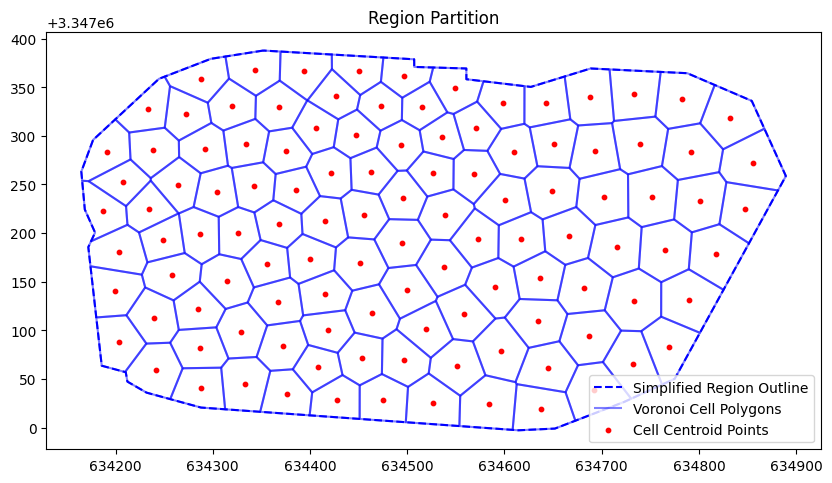

In [24]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cell Polygons")
cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroid Points")

plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach. We will use our cells to help measure area completion and divide work areas more efficiently. 

This section is concerned with:
- clustering of cells into trips
- prioritization of cells
- global trip efficiency
    - A.K.A. Multi-Trip Routing Problem (MTRP)
- Completion efficiency

Our planning inputs:
- cells and centroids
- base station location
    - where drones launch and land
- drone battery range
- target density per cell

In [5]:
from shapely.geometry import Point
import geopandas as gpd

# Cells
# points_gdf

# Base station location
base_station_coords = (634500,3347200)
base_station_gdf = gpd.GeoDataFrame(
    [{'geometry': Point(base_station_coords)}],
    crs=image_crs
)

# Drone battery range
trip_range = 500 # meters

# Cell densities


In [ ]:
from plant_search.image_preprocess import (
    generate_target_mask,
    correct_binary_mask,
    identify_targets,
)
import rasterio

# binary_mask = generate_target_mask(image) # Generate

# Load mask the easy way
binary_mask_path = "../outputs/region_binary_mask.tif"
with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    bin_transform = src.transform  # Get the affine transform
    bin_crs = src.crs  # Get the CRS

full_binary_mask = correct_binary_mask(binary_mask, original_image_shape)
targets_gdf = identify_targets(full_binary_mask, transform)


del full_binary_mask # Save us some memory
print(f"Number of targets (detected plants): {len(targets_gdf)}")

Number of targets (detected plants): 606


In [7]:
# # Instead of re-computing, save to image
# binary_mask_scaled = (binary_mask * 255).astype("uint8")

# with rasterio.open(file_path) as src:
#     image_region_crs = src.crs

# # Save the georeferenced binary mask with the correct scaling
# with rasterio.open(
#     "../outputs/region_binary_mask.tif",
#     "w",
#     driver="GTiff",
#     height=binary_mask.shape[0],
#     width=binary_mask.shape[1],
#     count=1,
#     dtype="uint8",
#     crs=image_region_crs,
#     transform=transform,
# ) as dst:
#     dst.write(binary_mask_scaled, 1)

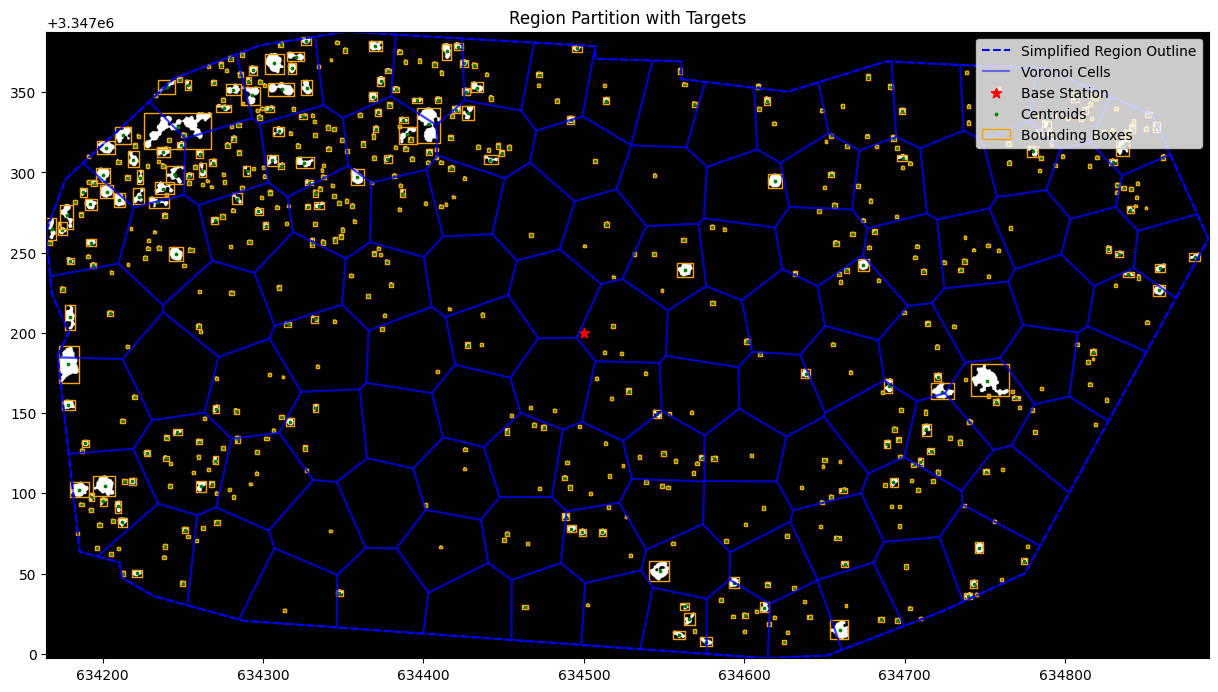

In [8]:
import matplotlib.patches as mpatches

# Display identified targets
fig, ax = plt.subplots(figsize=(15, 15))
# ax.imshow(image, extent=image_extent, alpha=0.8) # Display original image
ax.imshow(binary_mask, extent=image_extent, cmap='gray') # Show targets binary mask

# Region outline, cells, centroids
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cells") # Region cells
# cell_gdf.set_geometry('cell_centroids').plot(ax=ax, color="red", markersize=10, label="Cell Centroids")
base_station_gdf.plot(ax=ax, color='red', markersize=60, marker='*', label='Base Station')

targets_gdf.plot(ax=ax, color='green', markersize=3, label='Centroids') # Plot targets centroids
targets_gdf.set_geometry('bounding_box').plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=1.0) # Plot targets bounding boxes

# Fix legend for bounding boxes
handles, labels = ax.get_legend_handles_labels()
bounding_box_patch = mpatches.Patch(edgecolor='orange', facecolor='none', label='Bounding Boxes') # Add a custom handle for the bounding boxes
handles.append(bounding_box_patch)
labels.append('Bounding Boxes')

ax.legend(handles, labels, loc='upper right')
# plt.legend()
plt.title("Region Partition with Targets")
plt.show()

### Calculate Cell Densities

First-pass system to determine:
- Number of targets in each cell
- Distance to traverse all targets in each cell

In [45]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

def calculate_intra_cell_workload(cell_targets):
    """
    Calculate the intra-cell workload as the sum of the Minimum Spanning Tree (MST) distances.

    Parameters:
    - cell_targets: ndarray of shape (n, 2)
        Coordinates of the targets within a cell.

    Returns:
    - mst_distance: float
        Total intra-cell workload based on MST distances.
    """
    if cell_targets.shape[0] < 2:
        return 0

    # Compute pairwise distance matrix
    pairwise_dist = distance_matrix(cell_targets, cell_targets)

    mst = minimum_spanning_tree(pairwise_dist) # Compute MST and sum its edges
    mst_distance = mst.sum()

    return mst_distance


def calculate_cell_workloads(cells_gdf, targets_gdf):
    """
    Determine workload per cell from targets. 
    Updates 'cells_gdf' in-place, adding columns.

    Parameters:
    - cells_gdf: GeoDataFrame
        GeoDataFrame of cells (e.g., Voronoi or other tessellation).
    - targets_gdf: GeoDataFrame
        GeoDataFrame of target centroids.
    """
    # Assure GDFs are valid
    cells_gdf["geometry"] = cells_gdf["geometry"].apply(lambda geom: geom.buffer(0) if not geom.is_valid else geom)
    targets_gdf["geometry"] = targets_gdf["geometry"].apply(lambda geom: geom.buffer(0) if not geom.is_valid else geom)


    # 1. Associate targets with cells
    joined_gdf = gpd.sjoin(targets_gdf, cell_gdf, how="left", predicate="within")
    targets_gdf["parent_cell_id"] = joined_gdf["index_right"]  # Assign cell_id based on spatial join

    # 2. Determine total work in each cell
    # joined = gpd.sjoin(cells_gdf, targets_gdf, how="left", predicate="contains")
    # joined_gdf = gpd.sjoin(cells_gdf, targets_gdf, how="inner", predicate="intersects") #  Spatial join: count targets within each cell
    counts = joined_gdf.groupby(joined_gdf['parent_cell_id']).size()  # Count centroids in each cell
    cells_gdf["target_count"] = counts  # Add counts to cells GeoDataFrame
    cells_gdf["target_count"] = cells_gdf["target_count"].fillna(0).astype(int)  # Fill NaN with 0

     # 2. Calculate workloads for each cell
    workloads = []
    for cell_id, cell_row in cells_gdf.iterrows():
        # Get targets associated with the current cell
        cell_targets = targets_gdf[targets_gdf["parent_cell_id"] == cell_id]

        if not cell_targets.empty:
            # Extract target coordinates
            target_coords = np.array([(point.x, point.y) for point in cell_targets["geometry"]])
            workload = calculate_intra_cell_workload(target_coords)
        else:
            workload = 0  # No targets in the cell

        workloads.append(workload)

    cells_gdf["workload"] = workloads # Add workload as a new column in cells_gdf

    return joined_gdf


In [ ]:
from plant_search.macro_planning import (
    calculate_cell_workloads,
    plot_cells_with_targets,
    plot_cells_ids,
)

# In-place calculations
calculate_cell_workloads(cell_gdf, targets_gdf)
plot_cells_with_targets(cell_gdf)
# plot_cells_ids(cell_gdf)

# targets_gdf
# joined
# cell_gdf

,geometry,cell_centroid,cell_id,target_count,workload
0,"POLYGON ((634214.048 3347303.43, 634215.442 33...",POINT (634191.4965560734 3347283.7495535044),0,14,108.763127
1,"POLYGON ((634172.338 3347253.427, 634210.831 3...",POINT (634187.3117439159 3347223.051538306),1,4,61.024285
2,"POLYGON ((634212.292 3347208.545, 634224.159 3...",POINT (634203.6726181783 3347180.9930421743),2,3,70.244061
3,"POLYGON ((634256.093 3347351.128, 634250.642 3...",POINT (634233.1855918663 3347327.345267605),3,14,130.756818
4,"POLYGON ((634227.099 3347157.257, 634230.523 3...",POINT (634199.7809370067 3347140.0824813405),4,4,58.208083
...,...,...,...,...,...
108,"POLYGON ((634821.006 3347209.144, 634792.672 3...",POINT (634801.1051548251 3347232.4984873026),108,1,0.000000
109,"POLYGON ((634821.006 3347209.144, 634828.192 3...",POINT (634847.2436689751 3347224.9225135758),109,7,80.792017
110,"POLYGON ((634789.516 3347162.868, 634792.672 3...",POINT (634817.401749216 3347178.3792848485),110,6,47.095788
111,"POLYGON ((634828.192 3347252.422, 634820.699 3...",POINT (634855.1971551367 3347271.829805256),111,9,80.425266


### Data Relations

Finally, after much computation, we can now begin to treat our GDFs as database tables and relate them. 

First, we attempt to associate each target with a cell.

In [14]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp


# Step 2: Cluster Cells for Trips
def cluster_cells_by_workload(cell_workloads, max_workload):
    sorted_cells = sorted(cell_workloads.items(), key=lambda x: x[1], reverse=True)
    trips = []
    current_trip = []
    current_workload = 0

    for cell, workload in sorted_cells:
        if current_workload + workload > max_workload:
            trips.append(current_trip)
            current_trip = []
            current_workload = 0
        current_trip.append(cell)
        current_workload += workload
    if current_trip:
        trips.append(current_trip)
    return trips


# Step 3: Optimize Target Visits Within Each Trip
def optimize_trip_targets(trip_cells, targets, base_point):
    # Combine all targets from the trip's cells
    trip_targets = np.vstack([targets[cell] for cell in trip_cells])
    all_points = np.vstack([base_point, trip_targets])

    # Solve TSP for the trip
    num_points = len(all_points)
    dist_matrix = cdist(all_points, all_points)

    manager = pywrapcp.RoutingIndexManager(num_points, 1, 0)  # Start at base
    routing = pywrapcp.RoutingModel(manager)
    transit_callback_index = routing.RegisterTransitCallback(
        lambda i, j: int(dist_matrix[manager.IndexToNode(i)][manager.IndexToNode(j)])
    )
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    solution = routing.SolveWithParameters(search_parameters)

    # Extract optimized route
    if solution:
        route = []
        index = routing.Start(0)
        while not routing.IsEnd(index):
            route.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))
        return route
    return None

In [49]:
# Input data
max_workload = 1000  # Arbitrary drone capacity (sum of distances)

cell_workloads = cell_gdf['workload']
# print("Cell Workloads:", cell_workloads)

trips = cluster_cells_by_workload(cell_workloads, max_workload)
print("Trips:", trips)

# for trip in trips:
#     optimized_route = optimize_trip_targets(trip, targets, base_point)
#     print(f"Optimized Route for Trip {trip}: {optimized_route}")

Trips: [[112, 18, 19, 5, 36, 3, 62], [100, 24, 10, 37, 83, 0, 92, 25, 13], [20, 107, 33, 41, 106, 69, 17, 6, 93, 109, 8], [111, 101, 96, 88, 73, 66, 97, 29, 77, 11, 65, 103], [55, 9, 2, 14, 1, 51, 91, 22, 30, 26, 4, 98, 49, 90, 67, 86], [95, 105, 44, 110, 87, 75, 79, 27, 72, 21, 71, 70, 31, 102, 43, 80, 45, 56, 57, 40, 58, 61, 42, 104, 34, 68, 94, 78, 50], [59, 84, 47, 12, 7, 15, 16, 23, 28, 32, 35, 38, 39, 46, 48, 52, 53, 54, 60, 63, 64, 74, 76, 81, 82, 85, 89, 99, 108]]


## Micro Planning

Perform image analysis on each smaller section of our greater region.

In [12]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

# Path to the original image
# raster_path = "path_to_your_image.tif"

# Example: Select a Voronoi polygon by an attribute or ID
selected_partition = voronoi_gdf[voronoi_gdf['id'] == 0]


# Convert the selected polygon to GeoJSON-like format
# geometry = [mapping(selected_partition.geometry.iloc[0])]

# # Open the raster and clip it
# with rasterio.open(file_path) as src:
#     out_image, out_transform = mask(src, geometry, crop=True)
#     out_meta = src.meta.copy()

# # Update metadata for the clipped section
# out_meta.update({
#     "driver": "GTiff",
#     "height": out_image.shape[1],
#     "width": out_image.shape[2],
#     "transform": out_transform
# })
